In [7]:
import numpy as np
import matplotlib.pyplot as plt
import warnings

from sklearn.exceptions import ConvergenceWarning
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

from scipy.stats import norm

In [9]:
# =========================
# 0) CONFIG (F3) — Week 04
# =========================
INPUTS_PATH = "data/F3/initial_inputs.npy"
OUTPUTS_PATH = "data/F3/initial_outputs.npy"

BOUNDS = np.array([
    [0.0, 1.0],  # x1
    [0.0, 1.0],  # x2
    [0.0, 1.0],  # x3
])

RANDOM_SEED = 0

# Candidate generation
N_GLOBAL = 6000
N_LOCAL  = 2000
LOCAL_SIGMA = 0.15

# Distance penalty (avoid duplicates)
D_MIN = 0.03

# EI params (maximisation)
XI = 0.005

# Aux uncertainty models
RF_TREES = 200
GBM_ENSEMBLE = 6

# GP stability
GP_ALPHA = 1e-6  # nugget for numerical stability (recommended)

# =========================
# 0.5) IGNORE HARMLESS GP WARNING
# =========================
warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [10]:
# =========================
# 1) LOAD DATA
# =========================
X = np.load(INPUTS_PATH)
y = np.load(OUTPUTS_PATH)

assert X.ndim == 2 and X.shape[1] == 3, f"Expected X shape (n,3), got {X.shape}"
assert y.ndim == 1 and y.shape[0] == X.shape[0], f"Expected y shape (n,), got {y.shape}"

print("Loaded X:", X.shape, " y:", y.shape)
print("y stats min/mean/max:", float(y.min()), float(y.mean()), float(y.max()), " std:", float(y.std()))

best_idx = int(np.argmax(y))
x_best = X[best_idx]
y_best = float(y[best_idx])
print("Current best y:", y_best, "at x_best:", x_best)

Loaded X: (17, 3)  y: (17,)
y stats min/mean/max: -0.4391525756952428 -0.13113827437966782 -0.034835313350078584  std: 0.11181130286592843
Current best y: -0.034835313350078584 at x_best: [0.49258141 0.61159319 0.34017639]


In [11]:
# =========================
# 2) SURROGATE + UNCERTAINTY
# =========================
# Scale for stable training
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_s = x_scaler.fit_transform(X)
y_s = y_scaler.fit_transform(y.reshape(-1, 1)).ravel()

# ---- GP surrogate (primary) ----
# Wider upper bound is OK; warning is suppressed anyway
kernel = (
    C(1.0, (1e-2, 1e2)) *
    Matern(
        length_scale=np.ones(3),
        length_scale_bounds=(1e-2, 1e4),
        nu=2.5
    )
    + WhiteKernel(noise_level=1e-5, noise_level_bounds=(1e-8, 1e-1))
)

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=GP_ALPHA,              # <-- stability nugget
    normalize_y=False,
    n_restarts_optimizer=8,
    random_state=RANDOM_SEED
)
gp.fit(X_s, y_s)
print("GP kernel:", gp.kernel_)

def gp_predict_obj(Xcand):
    """GP mean/std in ORIGINAL objective units."""
    Xc_s = x_scaler.transform(Xcand)
    mu_s, sd_s = gp.predict(Xc_s, return_std=True)
    mu = y_scaler.inverse_transform(mu_s.reshape(-1, 1)).ravel()
    sd = sd_s * y_scaler.scale_[0]
    return mu, sd

# ---- RF uncertainty (tree ensemble spread) ----
rf = RandomForestRegressor(
    n_estimators=RF_TREES,
    min_samples_leaf=2,
    bootstrap=True,
    random_state=RANDOM_SEED,
    n_jobs=-1
)
rf.fit(X_s, y_s)

def rf_predict_obj(Xcand):
    Xc_s = x_scaler.transform(Xcand)
    preds = np.stack([t.predict(Xc_s) for t in rf.estimators_], axis=0)
    mu_s = preds.mean(axis=0)
    sd_s = preds.std(axis=0, ddof=1)
    mu = y_scaler.inverse_transform(mu_s.reshape(-1, 1)).ravel()
    sd = sd_s * y_scaler.scale_[0]
    return mu, sd

# ---- GBM ensemble uncertainty (seeded repeats) ----
gbm_models = []
for s in range(GBM_ENSEMBLE):
    m = HistGradientBoostingRegressor(
        max_depth=6,
        learning_rate=0.05,
        max_iter=250,
        random_state=RANDOM_SEED + s
    )
    m.fit(X_s, y_s)
    gbm_models.append(m)

def gbm_predict_obj(Xcand):
    Xc_s = x_scaler.transform(Xcand)
    preds = np.stack([m.predict(Xc_s) for m in gbm_models], axis=0)
    mu_s = preds.mean(axis=0)
    sd_s = preds.std(axis=0, ddof=1)
    mu = y_scaler.inverse_transform(mu_s.reshape(-1, 1)).ravel()
    sd = sd_s * y_scaler.scale_[0]
    return mu, sd

print("Surrogates fitted: GP + RF + GBM ensemble")


GP kernel: 1.07**2 * Matern(length_scale=[1e+04, 12.5, 0.255], nu=2.5) + WhiteKernel(noise_level=0.00846)
Surrogates fitted: GP + RF + GBM ensemble


In [12]:
# =========================
# 3) ACQUISITION
# =========================
rng = np.random.default_rng(RANDOM_SEED)

def expected_improvement(mu, sigma, y_best, xi=0.0):
    """EI for maximisation; mu/sigma in objective units."""
    sigma = np.maximum(sigma, 1e-12)
    imp = mu - y_best - xi
    Z = imp / sigma
    return imp * norm.cdf(Z) + sigma * norm.pdf(Z)

def min_dist_to_existing(Xcand, Xtrain):
    d = np.sqrt(((Xcand[:, None, :] - Xtrain[None, :, :]) ** 2).sum(axis=2))
    return d.min(axis=1)

# Candidate set: global + local around best
X_global = rng.uniform(BOUNDS[:, 0], BOUNDS[:, 1], size=(N_GLOBAL, 3))
X_local = x_best + rng.normal(0, LOCAL_SIGMA, size=(N_LOCAL, 3))
X_local = np.clip(X_local, BOUNDS[:, 0], BOUNDS[:, 1])

Xcand = np.vstack([X_global, X_local])

# GP EI + distance penalty
mu_gp, sd_gp = gp_predict_obj(Xcand)
ei = expected_improvement(mu_gp, sd_gp, y_best=y_best, xi=XI)

md = min_dist_to_existing(Xcand, X)
penalty = np.clip(md / D_MIN, 0.0, 1.0)   # 0 too close -> 1 far enough

score = ei * penalty
best_cand_idx = int(np.argmax(score))
x_next = Xcand[best_cand_idx]

print("\nSelected x_next (GP-EI):", x_next)
print("Min dist to existing:", float(md[best_cand_idx]))
print("Predicted (GP) mu ± sd:", float(mu_gp[best_cand_idx]), "±", float(sd_gp[best_cand_idx]))

# Optional: sanity-check alt picks using RF/GBM UCB
beta = 1.5
mu_rf, sd_rf = rf_predict_obj(Xcand)
mu_gb, sd_gb = gbm_predict_obj(Xcand)

ucb_rf = (mu_rf + beta * sd_rf) * penalty
ucb_gb = (mu_gb + beta * sd_gb) * penalty
idx_rf = int(np.argmax(ucb_rf))
idx_gb = int(np.argmax(ucb_gb))

print("\nAlt picks (sanity check):")
print("RF-UCB x:", Xcand[idx_rf], "  pred:", float(mu_rf[idx_rf]), "±", float(sd_rf[idx_rf]))
print("GBM-UCB x:", Xcand[idx_gb], " pred:", float(mu_gb[idx_gb]), "±", float(sd_gb[idx_gb]))




Selected x_next (GP-EI): [0.29482521 0.0100012  0.86013972]
Min dist to existing: 0.3442762012292331
Predicted (GP) mu ± sd: -0.05444461304122536 ± 0.07737615892193897

Alt picks (sanity check):
RF-UCB x: [0.420151   0.88416881 0.82481189]   pred: -0.11704923882572302 ± 0.11421029211370902
GBM-UCB x: [0.01018842 0.98856379 0.99087676]  pred: -0.13113827437966782 ± 7.548606644928053e-34


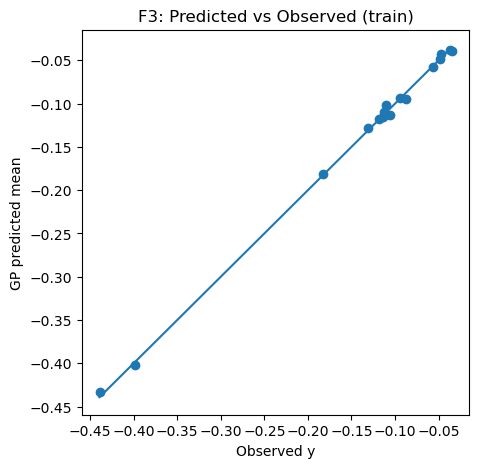

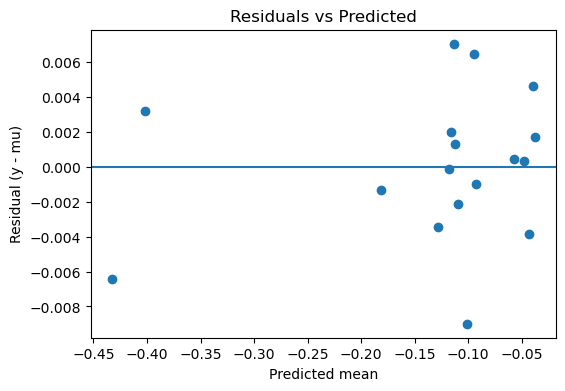

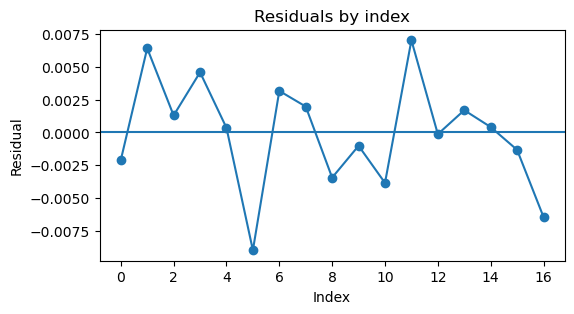

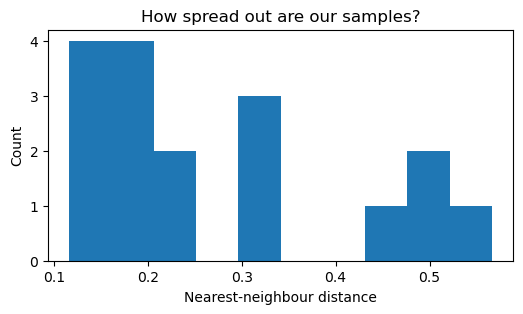

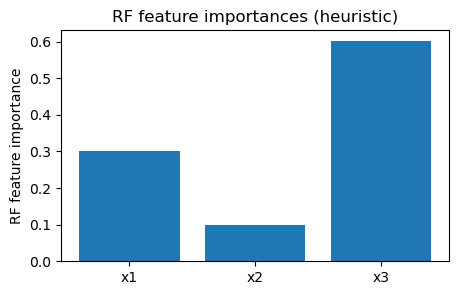

NN distance summary min/median/max: 0.11626815403249999 0.24660042507500665 0.5665979076180379


In [13]:
# =========================
# 4) DIAGNOSTICS
# =========================
# In-sample predicted vs observed (GP)
mu_train_s, sd_train_s = gp.predict(X_s, return_std=True)
mu_train = y_scaler.inverse_transform(mu_train_s.reshape(-1, 1)).ravel()
resid = y - mu_train

plt.figure(figsize=(5, 5))
plt.scatter(y, mu_train)
lims = [min(y.min(), mu_train.min()), max(y.max(), mu_train.max())]
plt.plot(lims, lims)
plt.xlabel("Observed y")
plt.ylabel("GP predicted mean")
plt.title("F3: Predicted vs Observed (train)")
plt.show()

plt.figure(figsize=(6, 4))
plt.scatter(mu_train, resid)
plt.axhline(0)
plt.xlabel("Predicted mean")
plt.ylabel("Residual (y - mu)")
plt.title("Residuals vs Predicted")
plt.show()

plt.figure(figsize=(6, 3))
plt.plot(resid, marker="o")
plt.axhline(0)
plt.xlabel("Index")
plt.ylabel("Residual")
plt.title("Residuals by index")
plt.show()

# Nearest-neighbour distances (spread / stuck-check)
def min_nn_dist(X):
    d = np.sqrt(((X[:, None, :] - X[None, :, :]) ** 2).sum(axis=2))
    np.fill_diagonal(d, np.inf)
    return d.min(axis=1)

nn = min_nn_dist(X)
plt.figure(figsize=(6, 3))
plt.hist(nn, bins=10)
plt.xlabel("Nearest-neighbour distance")
plt.ylabel("Count")
plt.title("How spread out are our samples?")
plt.show()

# RF feature importances (heuristic)
plt.figure(figsize=(5, 3))
plt.bar(["x1", "x2", "x3"], rf.feature_importances_)
plt.ylabel("RF feature importance")
plt.title("RF feature importances (heuristic)")
plt.show()

print("NN distance summary min/median/max:", float(nn.min()), float(np.median(nn)), float(nn.max()))



In [14]:
# =========================
# 5) OUTPUT: ONE ROW TO SUBMIT
# =========================
x_submit = x_next.reshape(1, -1)

print("\n=============================")
print("NEXT X TO SUBMIT (one row):")
print(x_submit)
print("Shape:", x_submit.shape)
print("Rounded (6 dp):")
print(np.round(x_submit, 6))


NEXT X TO SUBMIT (one row):
[[0.29482521 0.0100012  0.86013972]]
Shape: (1, 3)
Rounded (6 dp):
[[0.294825 0.010001 0.86014 ]]
